# 15. Matplotlib 확장 (히스토그램 · 박스플롯 · 파이 · subplot)

## 학습 목표
- `hist`로 분포를, `boxplot`으로 이상치를 시각화할 수 있다
- `pie`로 비율을 시각화할 수 있다
- `subplots`로 여러 차트를 한 화면에 배치할 수 있다

---

## 왜 배워야 하나요?

앞 단원의 선/막대/산점도만으로는 부족한 경우가 있습니다.
- **히스토그램**: 분포 모양(정규 분포? 한쪽으로 치우침?)
- **박스플롯**: 이상치가 많은지, 그룹 간 분포 비교
- **파이 차트**: 전체에서 차지하는 비중
- **subplot**: 여러 차트를 한번에 비교

실무 보고서는 여러 차트를 **한 화면에** 배치하는 경우가 대부분입니다.


In [1]:
# 아래에 코드를 작성하세요
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [21]:
df = pd.read_csv('./data/all_data.csv')

In [3]:
df.head(2)

,주문일자,주문번호,고객ID,상품코드,수량,상품명,카테고리,단가,매출,고객명,성별,연령,지역,가입일,회원등급,년도,월,날짜,요일
0,2024-01-02,ORD00001,C019,P001,3,노트북,컴퓨터,1350000,4050000,엄정화,여,54,대전,2022-04-01,골드,2024,1,2,1
1,2024-01-03,ORD00002,C028,P013,3,이어폰,음향,55000,165000,김유정,여,53,서울,2022-05-16,실버,2024,1,3,2


---
## 1. 히스토그램 - `hist`

**연속형 데이터의 분포**를 볼 때 사용합니다.


In [4]:
# 우리 고객의 데이터에서 연령이 있는데,
# 연령 구간을 10개 구간으로 잡아서 화면에 표시하자.
# 어느 나이대에 고객이 많이 몰려있는지 확인이 가능.

In [7]:
df['연령'].describe()

count    750.000000
mean      40.030667
std       12.088365
min       20.000000
25%       28.000000
50%       43.000000
75%       52.000000
max       59.000000
Name: 연령, dtype: float64

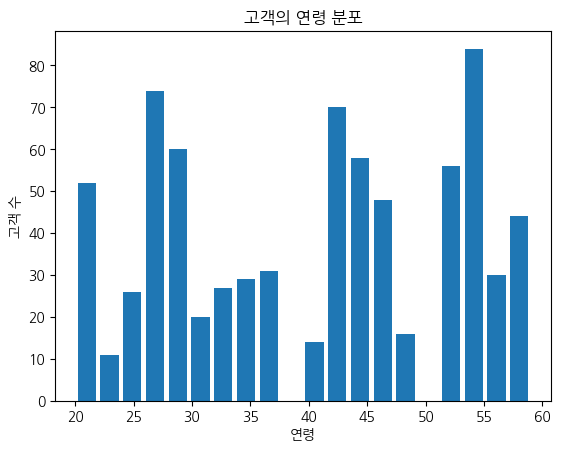

In [13]:
plt.hist( df['연령'] , rwidth=0.8 , bins = 20 )
plt.title('고객의 연령 분포')
plt.xlabel('연령')
plt.ylabel('고객 수')
plt.show()

---
## 2. 박스플롯 - `boxplot`

**이상치와 분포 비교**에 최적입니다.


In [55]:
# 매출 분포를 박스플롯으로 나타내시오.

In [56]:
df.head(2)

,주문일자,주문번호,고객ID,상품코드,수량,상품명,카테고리,단가,매출,고객명,성별,연령,지역,가입일,회원등급,년도,월,날짜,요일
0,2024-01-02,ORD00001,C019,P001,3,노트북,컴퓨터,1350000,4050000,엄정화,여,54,대전,2022-04-01,골드,2024,1,2,1
1,2024-01-03,ORD00002,C028,P013,3,이어폰,음향,55000,165000,김유정,여,53,서울,2022-05-16,실버,2024,1,3,2


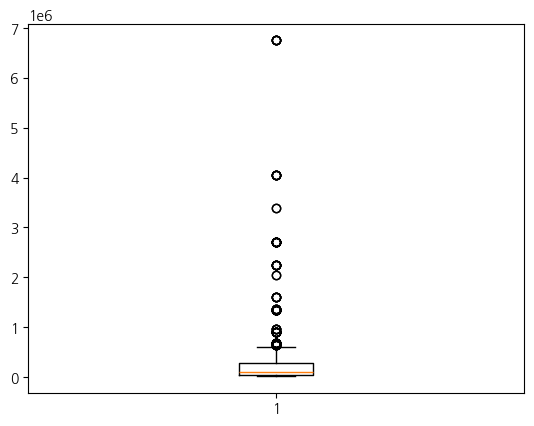

In [59]:
# 매출의 중앙값을 보여준다.  그리고 사분위수를 보여준다. 25% , 75% , 이상치(Outlier) -아웃라이어 를 보여준다.
plt.boxplot( df['매출'] )
plt.show()

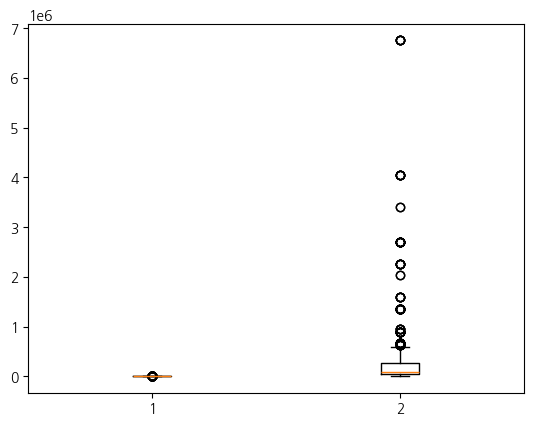

In [63]:
plt.boxplot( [ df['수량'], df['매출'] ]  )
plt.show()

---
## 3. 파이 차트 - `pie`

**비율**을 보여줄 때 씁니다. 조각이 너무 많으면(7개 이상) 막대가 더 낫습니다.


In [64]:
# 실무에서 가장 많이 사용 => 비율을 보여주고 싶을 때 사용한다.

In [65]:
# 회원등급을 비율로 보여주세요.

In [69]:
df_4 = df['회원등급'].value_counts()

In [70]:
df_4

회원등급
일반     330
실버     231
골드     109
VIP     80
Name: count, dtype: int64

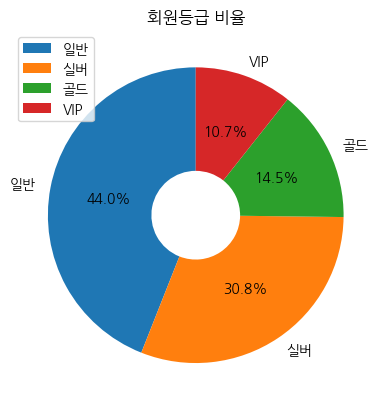

In [83]:
plt.pie( df_4 , labels=df_4.index, startangle=90, autopct='%.1f%%', wedgeprops={'width':0.7} )
plt.legend()
plt.title('회원등급 비율')
plt.savefig('차트2.png')
plt.show()

In [ ]:
# 아래에 코드를 작성하세요


---
## 4. `subplots` - 한 화면에 여러 차트

**가장 중요한 기능!** 보고서/대시보드에서 반드시 필요합니다.


In [ ]:
# 월별 매출 차트 => plot 선차트
# 카테고리별 매출 차트 => bar 
# 연령 분포 => 히스토그램
# 등급 비율 => 파이차트 

# 이 4개 차트를,  2행 2열의 영역에 배치시키자. 

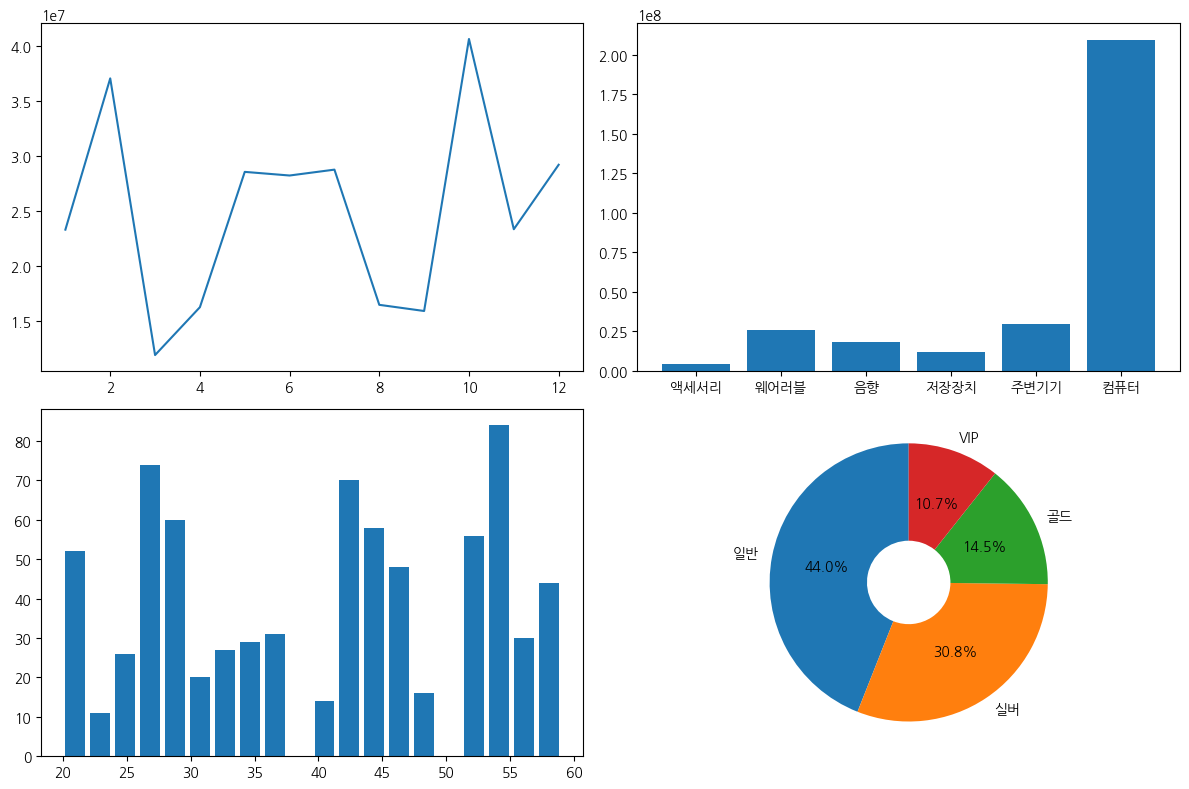

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

df_1 = df.groupby('월')['매출'].sum()

axes[0,0].plot( df_1.index, df_1.values )

df_2 = df.groupby('카테고리')['매출'].sum()

axes[0,1].bar( df_2.index, df_2.values )

axes[1,0].hist( df['연령'], bins = 20, rwidth=0.8 )

df_3 = df['회원등급'].value_counts()

axes[1,1].pie( df_3, labels=df_3.index, startangle=90, autopct='%.1f%%', wedgeprops={'width':0.7} )

plt.tight_layout()  # 각 차트끼리 겹치지 않게 니가 알아서 잘해라.
plt.show()

In [ ]:
# 아래에 코드를 작성하세요


---
## 실습문제

### 문제 1. 연령 히스토그램

`customers.csv`의 연령 분포를 bins=15로 히스토그램으로 그리세요.


In [ ]:
# 아래에 코드를 작성하세요


### 문제 2. 카테고리별 단가 박스플롯

`products.csv`에서 카테고리별 단가의 박스플롯을 그리세요.


In [ ]:
# 아래에 코드를 작성하세요


### 문제 3. 지역 비율 파이 차트

`customers.csv`에서 지역별 비율을 파이 차트로 그리세요.


In [ ]:
# 아래에 코드를 작성하세요


### 문제 4. 2x2 대시보드

`customers.csv`만 사용해 다음 4개 차트를 하나의 2x2 화면에 배치하세요.
1. 연령 히스토그램
2. 지역별 고객 수 막대
3. 회원등급 파이 차트
4. 성별 카운트 막대


In [ ]:
# 아래에 코드를 작성하세요
